In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("data/processed/monthly_merged.csv", encoding="utf-8-sig")

df["contract_month"] = pd.to_datetime(df["contract_month"])

df.head()

,sggCd,gu,contract_month,avg_sale_price,med_sale_price,avg_sale_price_per_m2,med_sale_price_per_m2,sale_count,avg_jeonse_deposit,med_jeonse_deposit,...,total_rent_count,monthly_count,monthly_ratio,jeonse_rate,gap_rate,sale_growth_1m,jeonse_growth_1m,growth_gap_1m,sale_volume_growth_1m,rent_volume_growth_1m
0,11110,종로구,2023-05-01,97098.529412,93495.0,1315.438781,1180.755760,34,59292.695238,59000.0,...,208,103,0.495192,0.600280,0.399720,NaN,NaN,NaN,NaN,NaN
1,11110,종로구,2023-06-01,125363.333333,118250.0,1382.048126,1282.217351,30,65890.121951,63000.0,...,160,78,0.487500,0.620928,0.379072,0.050637,0.086775,-0.036139,-0.117647,-0.230769
2,11110,종로구,2023-07-01,119448.181818,127500.0,1427.666364,1283.479442,22,62944.702970,55000.0,...,174,73,0.419540,0.587078,0.412922,0.033008,-0.023307,0.056315,-0.266667,0.087500
3,11110,종로구,2023-08-01,133262.000000,137225.0,1582.590432,1401.408319,40,59248.738739,48000.0,...,213,102,0.478873,0.532480,0.467520,0.108516,0.005424,0.103092,0.818182,0.224138
4,11110,종로구,2023-09-01,102655.208333,94250.0,1321.018893,1148.612117,48,57560.235849,51000.0,...,217,111,0.511521,0.578222,0.421778,-0.165281,-0.093574,-0.071707,0.200000,0.018779


# 1. 지역별 평균 매매가 확인

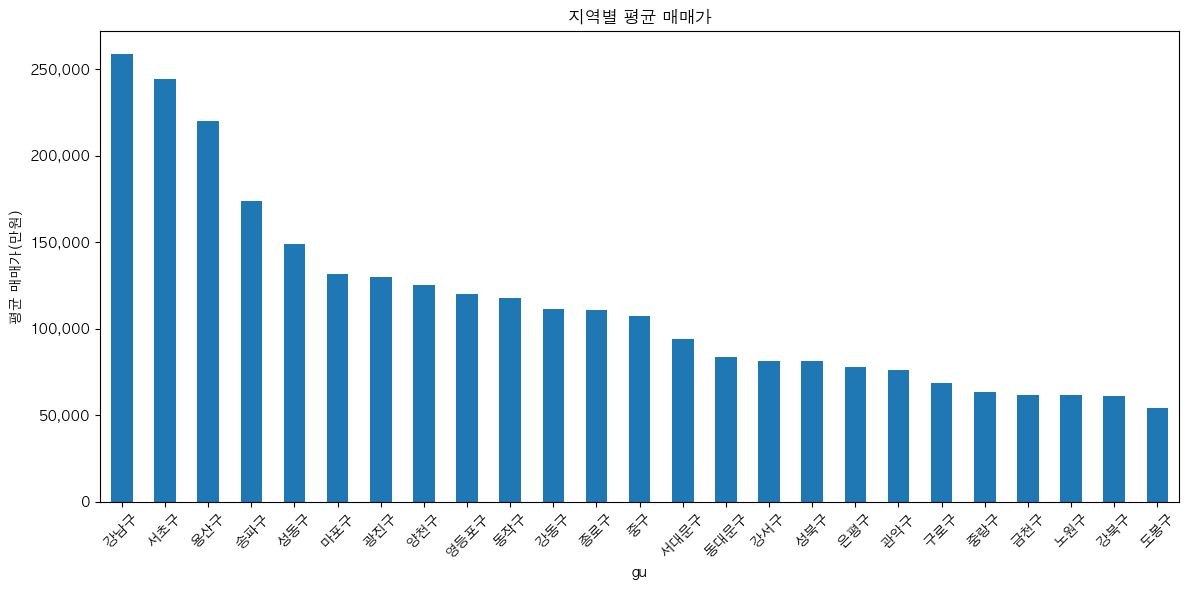

In [22]:
gu_sale = (
  df.groupby("gu")["avg_sale_price"]
  .mean()
  .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
gu_sale.plot(kind="bar")
plt.title("지역별 평균 매매가")
plt.ylabel("평균 매매가(만원)")
plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
  ticker.FuncFormatter(lambda x, pos: f"{int(x):,}")
)
plt.tight_layout()
plt.show()

# 2. 지역별 평균 전세가 확인

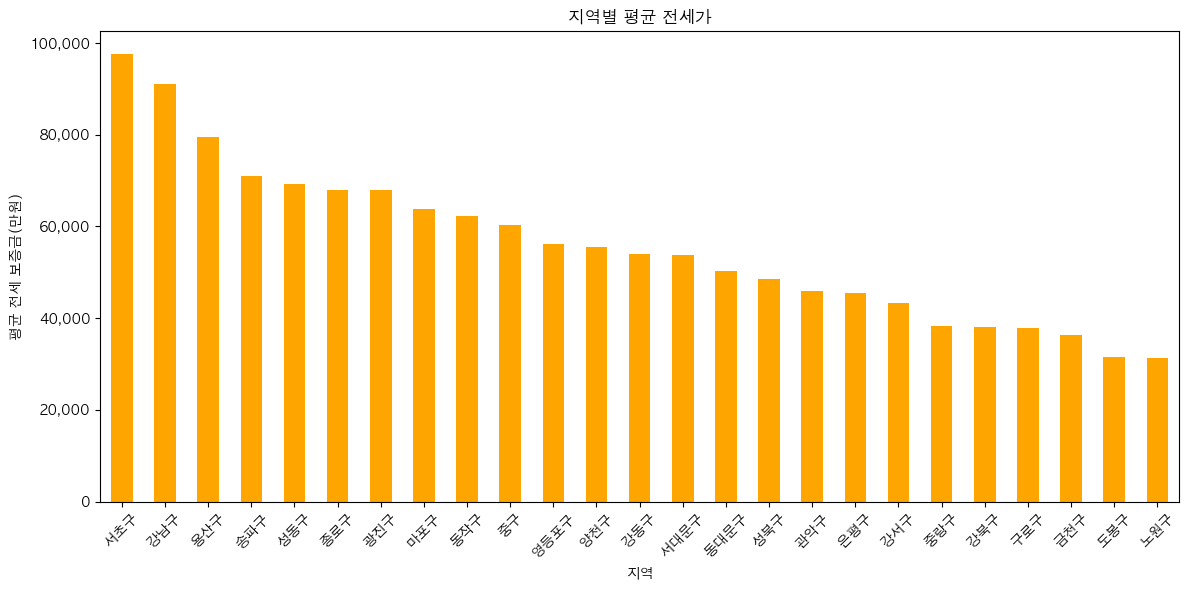

In [24]:
gu_jeonse = (
    df.groupby("gu")["avg_jeonse_deposit"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
gu_jeonse.plot(kind="bar", color="orange")
plt.title("지역별 평균 전세가")
plt.ylabel("평균 전세 보증금(만원)")
plt.xlabel("지역")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(
  ticker.FuncFormatter(lambda x, pos: f"{int(x):,}")
)
plt.tight_layout()
plt.show()

# 3. 월별 평균 매매가 변화 확인

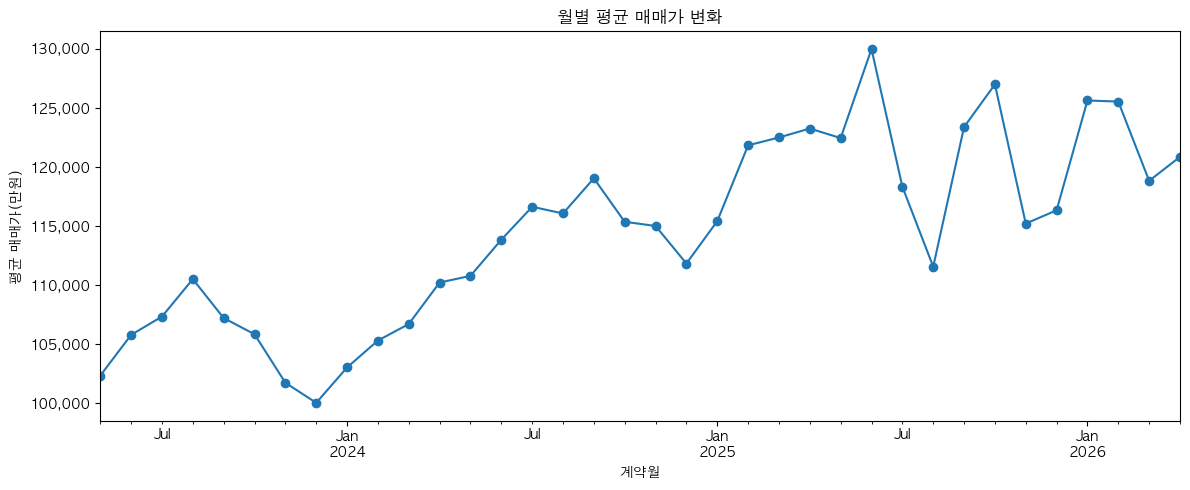

In [23]:
monthly_sale = (
  df.groupby("contract_month")["avg_sale_price"]
  .mean()
)

plt.figure(figsize=(12, 5))
monthly_sale.plot(marker="o")
plt.title("월별 평균 매매가 변화")
plt.ylabel("평균 매매가(만원)")
plt.xlabel("계약월")
plt.gca().yaxis.set_major_formatter(
  ticker.FuncFormatter(lambda x, pos: f"{int(x):,}")
)
plt.tight_layout()
plt.show()

# 4. 월별 평균 전세가 변화 확인

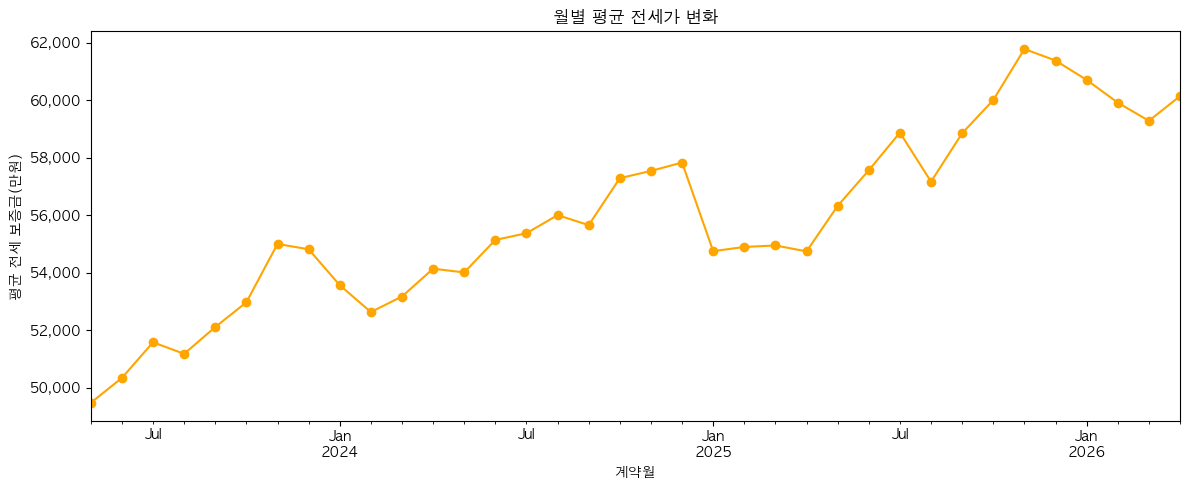

In [25]:
monthly_jeonse = (
    df.groupby("contract_month")["avg_jeonse_deposit"]
    .mean()
)

plt.figure(figsize=(12, 5))
monthly_jeonse.plot(marker="o", color="orange")
plt.title("월별 평균 전세가 변화")
plt.ylabel("평균 전세 보증금(만원)")
plt.xlabel("계약월")
plt.gca().yaxis.set_major_formatter(
  ticker.FuncFormatter(lambda x, pos: f"{int(x):,}")
)
plt.tight_layout()
plt.show()

# 5. 거래량 상위 5개 지역의 월별 매매 거래량 변화 확인

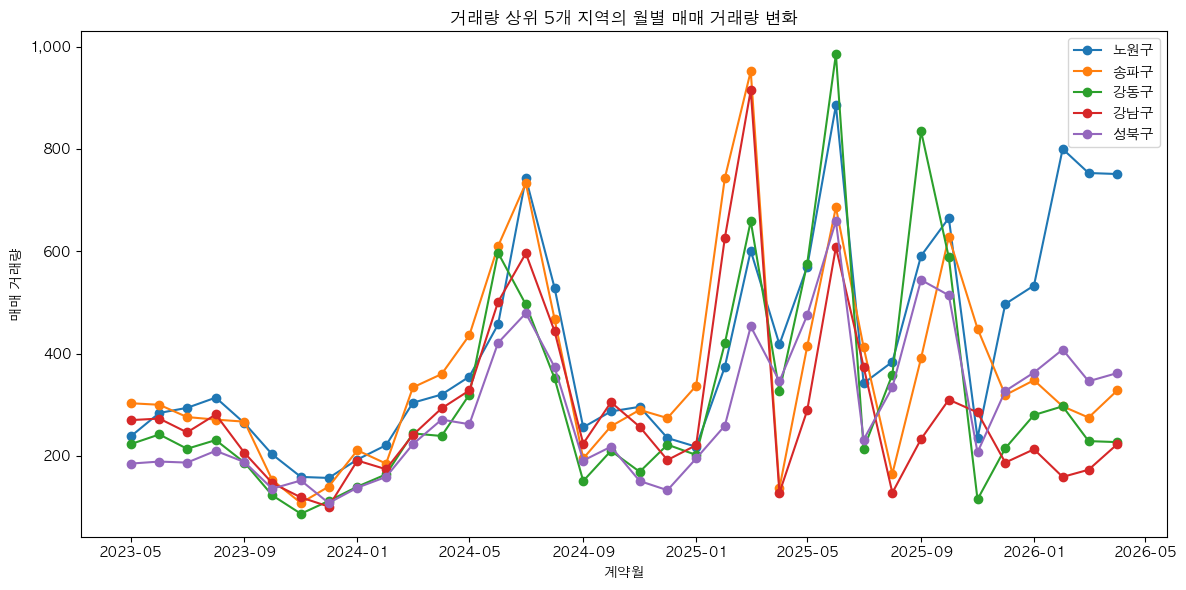

In [26]:
top5_gu = (
    df.groupby("gu")["sale_count"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

plt.figure(figsize=(12, 6))

for gu in top5_gu:
    gu_df = df[df["gu"] == gu]
    plt.plot(
        gu_df["contract_month"],
        gu_df["sale_count"],
        marker="o",
        label=gu
    )

plt.title("거래량 상위 5개 지역의 월별 매매 거래량 변화")
plt.ylabel("매매 거래량")
plt.xlabel("계약월")
plt.legend()
plt.gca().yaxis.set_major_formatter(
  ticker.FuncFormatter(lambda x, pos: f"{int(x):,}")
)
plt.tight_layout()
plt.show()